In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


# 1. Charger le fichier CSV depuis le chemin indiqué
file_path = r"D:\anaconda\envs\exo\APP\Portfolio\Car accident\accident.csv"
df = pd.read_csv(file_path)

# Affichage des premières lignes pour vérifier la structure
print("Aperçu du dataset :")
print(df.head())

# 2. Vérifier les valeurs manquantes dans 'Speed_of_Impact'
missing_speed = df['Speed_of_Impact'].isna().sum()
print(f"\nNombre de valeurs manquantes dans 'Speed_of_Impact' : {missing_speed}")

# Optionnel : statistiques descriptives de la vitesse d’impact
print("\nStatistiques descriptives de 'Speed_of_Impact' :")
print(df['Speed_of_Impact'].describe())


Aperçu du dataset :
   Age  Gender  Speed_of_Impact Helmet_Used Seatbelt_Used  Survived
0   56  Female             27.0          No            No         1
1   69  Female             46.0          No           Yes         1
2   46    Male             46.0         Yes           Yes         0
3   32    Male            117.0          No           Yes         0
4   60  Female             40.0         Yes           Yes         0

Nombre de valeurs manquantes dans 'Speed_of_Impact' : 3

Statistiques descriptives de 'Speed_of_Impact' :
count    197.000000
mean      70.441624
std       30.125298
min       20.000000
25%       43.000000
50%       71.000000
75%       95.000000
max      119.000000
Name: Speed_of_Impact, dtype: float64


In [3]:

# 3. Comparer la distribution des vitesses entre survivants et non-survivants
# Séparer les données en fonction de la variable 'Survived'
survivors = df[df['Survived'] == 1]
non_survivors = df[df['Survived'] == 0]

print("\nStatistiques pour les survivants :")
print(survivors['Speed_of_Impact'].describe())
print("\nStatistiques pour les non-survivants :")
print(non_survivors['Speed_of_Impact'].describe())



Statistiques pour les survivants :
count    100.000000
mean      71.700000
std       29.401951
min       20.000000
25%       45.750000
50%       73.500000
75%       95.500000
max      119.000000
Name: Speed_of_Impact, dtype: float64

Statistiques pour les non-survivants :
count     97.000000
mean      69.144330
std       30.952245
min       20.000000
25%       42.000000
50%       70.000000
75%       95.000000
max      119.000000
Name: Speed_of_Impact, dtype: float64


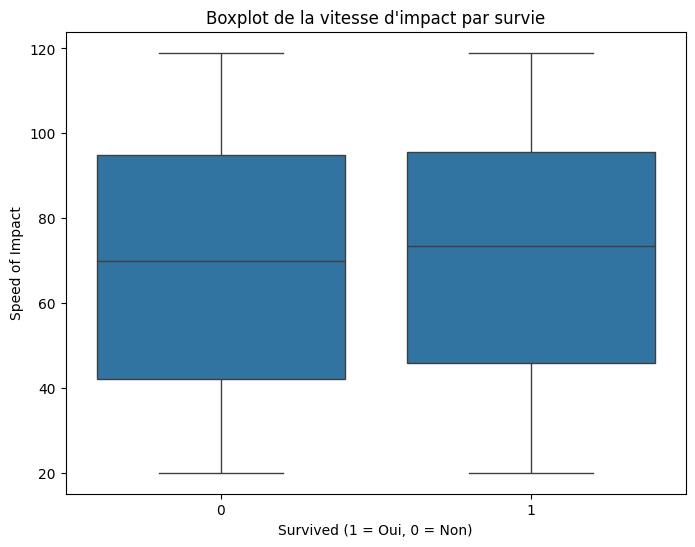

In [4]:

# 4. Visualiser la distribution avec un boxplot et un histogramme

# Boxplot de la vitesse d'impact par survie
plt.figure(figsize=(8, 6))
sns.boxplot(x='Survived', y='Speed_of_Impact', data=df)
plt.title("Boxplot de la vitesse d'impact par survie")
plt.xlabel("Survived (1 = Oui, 0 = Non)")
plt.ylabel("Speed of Impact")
plt.show()


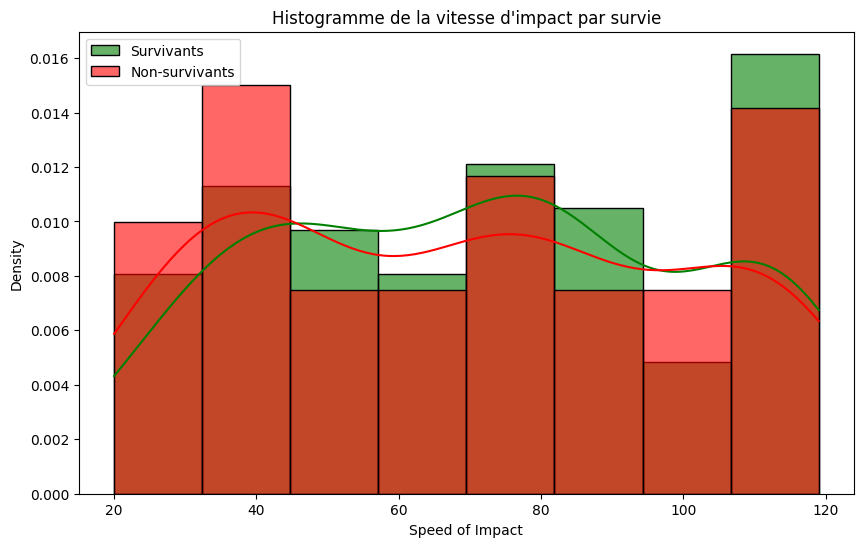

In [5]:

# Histogramme avec courbes de densité pour chaque groupe
plt.figure(figsize=(10, 6))
sns.histplot(survivors['Speed_of_Impact'].dropna(), color='green', label='Survivants', kde=True, stat="density", alpha=0.6)
sns.histplot(non_survivors['Speed_of_Impact'].dropna(), color='red', label='Non-survivants', kde=True, stat="density", alpha=0.6)
plt.title("Histogramme de la vitesse d'impact par survie")
plt.xlabel("Speed of Impact")
plt.legend()
plt.show()


In [6]:

# 5. Test statistique : comparaison des moyennes avec un test t de Welch (pour variances inégales)
speeds_survivors = survivors['Speed_of_Impact'].dropna()
speeds_non_survivors = non_survivors['Speed_of_Impact'].dropna()

t_stat, p_value = ttest_ind(speeds_survivors, speeds_non_survivors, equal_var=False)
print("\nRésultats du test t pour la différence de vitesse d'impact :")
print("t-statistique =", t_stat)
print("p-value =", p_value)

if p_value < 0.05:
    print("La différence est statistiquement significative (p < 0.05).")
else:
    print("La différence n'est pas statistiquement significative (p >= 0.05).")



Résultats du test t pour la différence de vitesse d'impact :
t-statistique = 0.5938368485207859
p-value = 0.5533140963486943
La différence n'est pas statistiquement significative (p >= 0.05).


In [8]:
# 2. Créer un tableau croisé (Helmet_Used, Seatbelt_Used) vs Survived
crosstab = pd.crosstab(index=[df['Helmet_Used'], df['Seatbelt_Used']], 
                       columns=df['Survived'])

print("Tableau croisé (Helmet_Used, Seatbelt_Used) vs Survived :\n")
print(crosstab)

# 3. Calculer les taux de survie pour chaque catégorie
#    On calcule la proportion de survivants dans chaque groupe
#    (ligne par ligne, Survived=1 / total de la ligne)
survival_rate_table = crosstab.apply(lambda row: row / row.sum(), axis=1)
print("\nTaux de survie pour chaque catégorie :\n")
print(survival_rate_table)


Tableau croisé (Helmet_Used, Seatbelt_Used) vs Survived :

Survived                    0   1
Helmet_Used Seatbelt_Used        
No          No             24  20
            Yes            18  27
Yes         No             23  22
            Yes            34  32

Taux de survie pour chaque catégorie :

Survived                          0         1
Helmet_Used Seatbelt_Used                    
No          No             0.545455  0.454545
            Yes            0.400000  0.600000
Yes         No             0.511111  0.488889
            Yes            0.515152  0.484848


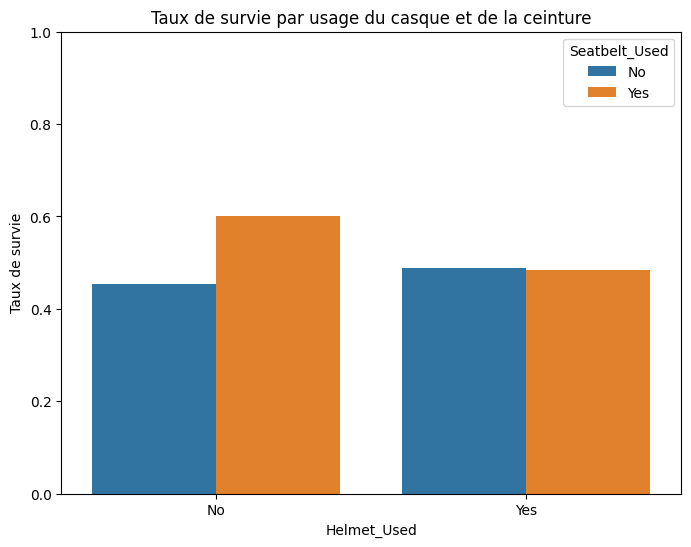

In [9]:

# 4. Visualiser avec un graphique en barres
#    On peut d’abord calculer le taux de survie par groupby puis tracer un barplot
survival_rate = df.groupby(['Helmet_Used', 'Seatbelt_Used'])['Survived'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=survival_rate, 
            x='Helmet_Used', 
            y='Survived', 
            hue='Seatbelt_Used')
plt.title("Taux de survie par usage du casque et de la ceinture")
plt.ylabel("Taux de survie")
plt.ylim(0, 1)
plt.xlabel("Helmet_Used")
plt.legend(title="Seatbelt_Used")
plt.show()


In [10]:

# 5. Effectuer un test du Chi² pour vérifier la significativité statistique
chi2, p, dof, expected = chi2_contingency(crosstab)

print("\nRésultats du test Chi² :")
print(f"Chi² = {chi2:.4f}")
print(f"p-value = {p:.4f}")
print(f"Degrés de liberté = {dof}")
print("Valeurs attendues :\n", expected)

if p < 0.05:
    print("La relation est statistiquement significative (p < 0.05).")
else:
    print("La relation n'est pas statistiquement significative (p >= 0.05).")



Résultats du test Chi² :
Chi² = 2.2267
p-value = 0.5267
Degrés de liberté = 3
Valeurs attendues :
 [[21.78  22.22 ]
 [22.275 22.725]
 [22.275 22.725]
 [32.67  33.33 ]]
La relation n'est pas statistiquement significative (p >= 0.05).


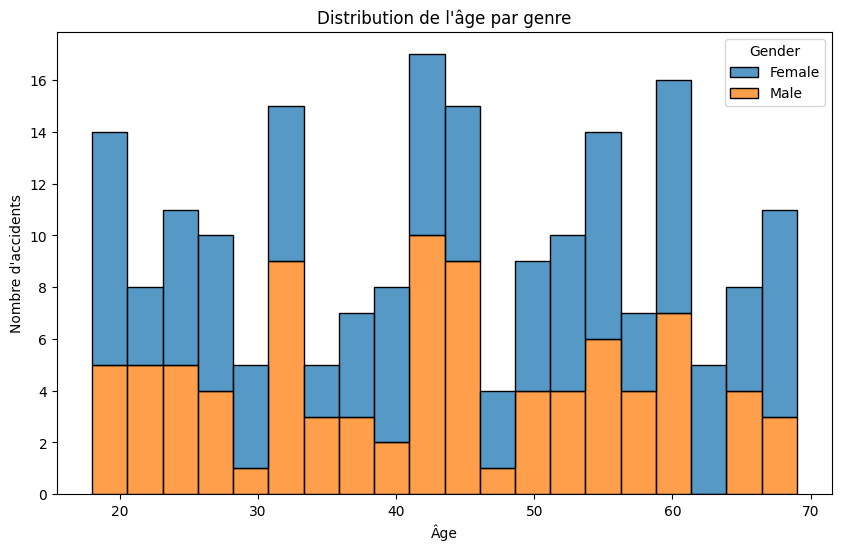

In [11]:
# 2️⃣ Visualiser la distribution de l’âge par genre avec un histogramme
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Gender', bins=20, multiple='stack')
plt.title("Distribution de l'âge par genre")
plt.xlabel("Âge")
plt.ylabel("Nombre d'accidents")
plt.show()


In [12]:

# 3️⃣ Analyser les proportions d’accidents selon les groupes d’âge
# Définir des groupes d'âge
bins = [0, 20, 40, 60, 80, 100]
labels = ["0-20", "20-40", "40-60", "60-80", "80-100"]
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Calculer le nombre et la proportion d'accidents dans chaque groupe d'âge
age_group_counts = df['Age_Group'].value_counts().sort_index()
age_group_proportions = age_group_counts / len(df) * 100

print("\nRépartition des accidents par groupe d'âge:")
print(age_group_counts)
print("\nProportions (%):")
print(age_group_proportions)


Répartition des accidents par groupe d'âge:
Age_Group
0-20      10
20-40     69
40-60     85
60-80     36
80-100     0
Name: count, dtype: int64

Proportions (%):
Age_Group
0-20       5.0
20-40     34.5
40-60     42.5
60-80     18.0
80-100     0.0
Name: count, dtype: float64


In [13]:
# 1️⃣ Remplir les valeurs manquantes (imputation) en évitant la modification en chaîne
df.loc[:, 'Age'] = df['Age'].fillna(df['Age'].median())
df.loc[:, 'Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df.loc[:, 'Speed_of_Impact'] = df['Speed_of_Impact'].fillna(df['Speed_of_Impact'].median())
df.loc[:, 'Helmet_Used'] = df['Helmet_Used'].fillna(df['Helmet_Used'].mode()[0])
df.loc[:, 'Seatbelt_Used'] = df['Seatbelt_Used'].fillna(df['Seatbelt_Used'].mode()[0])

# Vérifier qu'il ne reste plus de valeurs manquantes
print("Valeurs manquantes après imputation :")
print(df.isnull().sum())


Valeurs manquantes après imputation :
Age                0
Gender             0
Speed_of_Impact    0
Helmet_Used        0
Seatbelt_Used      0
Survived           0
Age_Group          0
dtype: int64


In [14]:

# 2️⃣ Encoder les variables catégoriques
df_encoded = pd.get_dummies(df, columns=['Gender', 'Helmet_Used', 'Seatbelt_Used'], drop_first=True)

# 3️⃣ Régression logistique
X = df_encoded[['Age', 'Speed_of_Impact', 'Gender_Male', 'Helmet_Used_Yes', 'Seatbelt_Used_Yes']]
y = df_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 4️⃣ Analyse des résultats
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))



Rapport de classification :
              precision    recall  f1-score   support

           0       0.58      0.68      0.62        22
           1       0.50      0.39      0.44        18

    accuracy                           0.55        40
   macro avg       0.54      0.54      0.53        40
weighted avg       0.54      0.55      0.54        40



## Ajustement meilleurs paramètres possibles

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV  # Outils pour diviser les données et rechercher les meilleurs paramètres (validation croisée)
from sklearn.linear_model import LogisticRegression  # Modèle de régression logistique (prédiction d'une variable binaire)
from sklearn.metrics import classification_report  # Pour afficher un résumé de la performance du modèle

# Encoder les variables catégoriques (transforme les données non numériques en données numériques)
df_encoded = pd.get_dummies(df, columns=['Gender', 'Helmet_Used', 'Seatbelt_Used'], drop_first=True)

# Définir les variables d'entrée (features) et la variable cible (target)
X = df_encoded[['Age', 'Speed_of_Impact', 'Gender_Male', 'Helmet_Used_Yes', 'Seatbelt_Used_Yes']]
y = df_encoded['Survived']

# Diviser les données en ensemble d'entraînement et de test 
# (train_test_split sépare les données pour entraîner le modèle et pour le tester ensuite)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Définir la grille de paramètres à tester pour la régression logistique
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # C contrôle la pénalisation (plus C est grand, moins le modèle est pénalisé)
    'penalty': ['l1', 'l2'],       # L1 (sélectionne certaines variables en rendant d'autres coefficients nuls) ou L2 (réduit tous les coefficients)
    'solver': ['liblinear']        # 'liblinear' est adapté aux petits jeux de données et supporte L1 et L2
}

# Créer GridSearchCV pour tester différentes combinaisons de paramètres (cv=5 utilise 5 divisions des données pour valider)
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')

# Entraîner GridSearchCV sur l'ensemble d'entraînement
grid_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres et le score associé
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleure exactitude (score) :", grid_search.best_score_)

# Utiliser le meilleur modèle trouvé pour prédire sur l'ensemble de test
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

# Afficher le rapport de classification (précision, rappel, f1-score) du meilleur modèle
print("\nRapport de classification avec le meilleur modèle :")
print(classification_report(y_test, y_pred_best))


Meilleurs paramètres : {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Meilleure exactitude (score) : 0.55625

Rapport de classification avec le meilleur modèle :
              precision    recall  f1-score   support

           0       0.48      0.55      0.51        22
           1       0.33      0.28      0.30        18

    accuracy                           0.42        40
   macro avg       0.41      0.41      0.41        40
weighted avg       0.41      0.42      0.42        40



## choix Random forest comme modèle

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV  # Séparation des données et recherche des meilleurs paramètres (validation croisée)
from sklearn.ensemble import RandomForestClassifier  # Modèle d'arbres aléatoires (capable de capturer des relations non linéaires)
from sklearn.metrics import classification_report  # Pour afficher la performance du modèle



# Encoder les variables catégoriques (transformation des données textuelles en numérique)
df_encoded = pd.get_dummies(df, columns=['Gender', 'Helmet_Used', 'Seatbelt_Used'], drop_first=True)

# Définir les variables explicatives (features) et la variable cible (target)
X = df_encoded[['Age', 'Speed_of_Impact', 'Gender_Male', 'Helmet_Used_Yes', 'Seatbelt_Used_Yes']]
y = df_encoded['Survived']

# Séparer les données en ensemble d'entraînement et de test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Définir la grille de paramètres pour RandomForestClassifier
param_grid_rf = {
    'n_estimators': [10, 50, 100, 200],   # Nombre d'arbres dans la forêt (plus il y a d'arbres, plus le modèle peut être robuste)
    'max_depth': [None, 3, 5, 7],           # Profondeur maximale des arbres (None = pas de limite)
    'min_samples_split': [2, 5, 10]         # Nombre minimum d'échantillons nécessaires pour diviser un noeud
}

# GridSearchCV teste plusieurs combinaisons de paramètres via une validation croisée (ici cv=5, c'est-à-dire 5 divisions des données)
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)

# Afficher les meilleurs paramètres et le score obtenu en validation croisée
print("Meilleurs paramètres RandomForest :", grid_search_rf.best_params_)
print("Meilleure exactitude (score) :", grid_search_rf.best_score_)

# Utiliser le meilleur modèle trouvé pour prédire sur l'ensemble de test
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

# Afficher le rapport de classification (précision, rappel, f1-score)
print("\nRapport de classification avec RandomForest :")
print(classification_report(y_test, y_pred_rf))


Meilleurs paramètres RandomForest : {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 10}
Meilleure exactitude (score) : 0.55625

Rapport de classification avec RandomForest :
              precision    recall  f1-score   support

           0       0.56      0.64      0.60        22
           1       0.47      0.39      0.42        18

    accuracy                           0.53        40
   macro avg       0.51      0.51      0.51        40
weighted avg       0.52      0.53      0.52        40



In [17]:

coeffs = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
})
print("\nCoefficients du modèle :")
print(coeffs)


Coefficients du modèle :
            Variable  Coefficient
0                Age     0.011093
1    Speed_of_Impact    -0.001051
2        Gender_Male     0.660313
3    Helmet_Used_Yes    -0.252034
4  Seatbelt_Used_Yes     0.228250
